# Residual Learning Denoising MLP for Ranging

## Role and Goal
PyTorch 기반 신호 처리 모델로, 10 x 10 공간의 4개 앵커 거리 측정에서 AWGN 오차를 제거한다.

## Physical Setup
- 공간: 10 x 10
- 앵커: 4개 모서리
- 거리 정규화 상수: 15.0
- 노이즈 표준편차 정규화 상수: sigma_max = 10.0

## Input and Target
- 입력 거리 4차원: d_norm = d_i / 15.0
- 입력 노이즈 지표 1차원: sigma_norm = sigma / 10.0
- 모델 출력 4차원: 정규화 잔차 노이즈 예측
- 타겟: Noise_target = (d_i - d_true) / 15.0

## Reconstruction
Clean Distance = (d_norm - Predicted Noise) x 15.0

## Model Architecture
- Input: 5
- Hidden: 64 -> 64 with nn.GELU()
- Output: 4 (linear)

In [9]:
import importlib
import subprocess
import sys
from pathlib import Path


def ensure_package(pkg_name: str) -> None:
    try:
        importlib.import_module(pkg_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg_name])


for pkg in ["numpy", "h5py", "torch", "matplotlib"]:
    ensure_package(pkg)

import h5py
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DIST_NORM = 15.0
SIGMA_MAX = 10.0

print("Device:", DEVICE)
print("DIST_NORM:", DIST_NORM, "SIGMA_MAX:", SIGMA_MAX)

Device: cuda
DIST_NORM: 15.0 SIGMA_MAX: 10.0


In [10]:
ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
RESULT_DIR = ROOT / "result"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# 요청사항: IMM가 아닌 CV 데이터 파일을 고정 사용
H5_IN = DATA_DIR / "simulation_data.h5"
if not H5_IN.exists():
    raise FileNotFoundError(f"Required file not found: {H5_IN}")

H5_OUT = DATA_DIR / f"{H5_IN.stem}_residual_mlp_corrected.h5"
PT_OUT = RESULT_DIR / "denoising_residual_mlp.pt"

print("Input h5:", H5_IN)
print("Output h5:", H5_OUT)
print("Output pt:", PT_OUT)


def swap_first_last_dims(arr: np.ndarray) -> np.ndarray:
    """Convert MATLAB-written H5 layout to MATLAB-like in-memory layout.

    MATLAB arrays are column-major, and h5py reads dimensions effectively reversed.
    To recover original MATLAB axis order, reverse all axes.
    Example: [5, 100000, 10, 4] -> [4, 10, 100000, 5]
    """
    if arr.ndim <= 1:
        return arr
    return np.transpose(arr, axes=tuple(reversed(range(arr.ndim))))


def to_original_ranging_layout(arr_4psn: np.ndarray, raw_shape: tuple[int, ...]) -> np.ndarray:
    """Convert internal MATLAB-like layout back to raw H5 layout."""
    arr_h5 = np.transpose(arr_4psn, axes=tuple(reversed(range(arr_4psn.ndim))))
    if arr_h5.shape != raw_shape:
        raise ValueError(f"Shape mismatch: got {arr_h5.shape}, expected {raw_shape}")
    return arr_h5


raw_data = {}
data = {}
with h5py.File(H5_IN, "r") as h5:
    for key in h5.keys():
        arr = np.asarray(h5[key])
        raw_data[key] = arr
        data[key] = swap_first_last_dims(arr)

ranging_meas = data["ranging"].astype(np.float32)      # expected: (4, 10, 100000, 5)
true_state = data["true_state"].astype(np.float32)      # expected: (4, 10, 100000, 5)

# MATLAB dataGenerate.m anchor 순서를 그대로 사용:
# (0,10), (0,0), (10,0), (10,10)
anchors = np.array([
    [0.0, 10.0],
    [0.0, 0.0],
    [10.0, 0.0],
    [10.0, 10.0],
], dtype=np.float32)

if ranging_meas.shape[0] != 4:
    raise ValueError(f"Expected 4 anchor channels, got {ranging_meas.shape}")

pos = np.moveaxis(true_state[0:2, ...], 0, -1)  # (P, S, N, 2)
ranging_true = np.linalg.norm(pos[..., None, :] - anchors[None, None, None, :, :], axis=-1)
ranging_true = np.moveaxis(ranging_true, -1, 0).astype(np.float32)  # (4, P, S, N)

print("ranging_meas:", ranging_meas.shape)
print("ranging_true:", ranging_true.shape)
print("anchors (MATLAB order):", anchors.tolist())

Input h5: c:\Users\myhom\codebase\localization-filters-2d\data\simulation_data.h5
Output h5: c:\Users\myhom\codebase\localization-filters-2d\data\simulation_data_residual_mlp_corrected.h5
Output pt: c:\Users\myhom\codebase\localization-filters-2d\result\denoising_residual_mlp.pt
ranging_meas: (4, 10, 100000, 5)
ranging_true: (4, 10, 100000, 5)
anchors (MATLAB order): [[0.0, 10.0], [0.0, 0.0], [10.0, 0.0], [10.0, 10.0]]


In [11]:
# Residual target and 5-D input construction
# Noise_target = (d_meas - d_true) / DIST_NORM
noise_target = (ranging_meas - ranging_true) / DIST_NORM

# d_norm = d_meas / DIST_NORM
ranging_norm = ranging_meas / DIST_NORM

P, S, N = ranging_meas.shape[1], ranging_meas.shape[2], ranging_meas.shape[3]

# flatten order: (4, P, S, N) -> (P, S, N, 4) -> (M, 4)
X_dist = np.transpose(ranging_norm, (1, 2, 3, 0)).reshape(-1, 4).astype(np.float32)
Y_noise = np.transpose(noise_target, (1, 2, 3, 0)).reshape(-1, 4).astype(np.float32)
D_true = np.transpose(ranging_true, (1, 2, 3, 0)).reshape(-1, 4).astype(np.float32)

# 노이즈 분산 고정 목록: [0.01, 0.1, 1, 10, 100]
noise_variances = np.array([0.01, 0.1, 1.0, 10.0, 100.0], dtype=np.float32)
if N != len(noise_variances):
    raise ValueError(f"Expected {len(noise_variances)} noise levels, got N={N}")

# sigma = sqrt(variance), sigma_norm = sigma / SIGMA_MAX
sigma_levels = np.sqrt(noise_variances).astype(np.float32)
expected_sigma_max = float(np.max(sigma_levels))
if not np.isclose(SIGMA_MAX, expected_sigma_max):
    raise ValueError(f"SIGMA_MAX must be {expected_sigma_max} for given variances, got {SIGMA_MAX}")

sigma_by_noise = sigma_levels.copy()
noise_idx_full = np.tile(np.arange(N, dtype=np.int64), P * S)
sigma_norm_full = (sigma_levels[noise_idx_full] / SIGMA_MAX).astype(np.float32).reshape(-1, 1)

# Final model input: [d_norm(4), sigma_norm(1)]
X_input = np.concatenate([X_dist, sigma_norm_full], axis=1).astype(np.float32)

num_total = X_input.shape[0]
perm = np.random.default_rng(SEED).permutation(num_total)
tr_end = int(0.8 * num_total)
va_end = int(0.9 * num_total)

idx_train = perm[:tr_end]
idx_val = perm[tr_end:va_end]
idx_test = perm[va_end:]

X_train, Y_train = X_input[idx_train], Y_noise[idx_train]
X_val, Y_val = X_input[idx_val], Y_noise[idx_val]
X_test, Y_test = X_input[idx_test], Y_noise[idx_test]
D_true_test = D_true[idx_test]
D_noisy_test = X_dist[idx_test] * DIST_NORM

print("noise_variances:", noise_variances)
print("sigma_levels:", sigma_levels)
print("sigma_norm range:", float(np.min(sigma_norm_full)), "~", float(np.max(sigma_norm_full)))
print("X_input shape:", X_input.shape)
print("Y_noise shape:", Y_noise.shape)
print("Train/Val/Test:", len(idx_train), len(idx_val), len(idx_test))

noise_variances: [1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
sigma_levels: [ 0.1         0.31622776  1.          3.1622777  10.        ]
sigma_norm range: 0.009999999776482582 ~ 1.0
X_input shape: (5000000, 5)
Y_noise shape: (5000000, 4)
Train/Val/Test: 4000000 500000 500000


In [12]:
class DenoisingResidualMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 4),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def make_loader(X_np: np.ndarray, Y_np: np.ndarray, batch_size: int = 4096, shuffle: bool = True):
    ds = TensorDataset(torch.from_numpy(X_np), torch.from_numpy(Y_np))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss = 0.0
    total_count = 0

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        if train_mode:
            optimizer.zero_grad()

        pred = model(xb)
        loss = criterion(pred, yb)

        if train_mode:
            loss.backward()
            optimizer.step()

        bsz = xb.shape[0]
        total_loss += loss.item() * bsz
        total_count += bsz

    return total_loss / max(total_count, 1)


@torch.no_grad()
def predict_noise(model: nn.Module, X_np: np.ndarray, batch_size: int = 65536) -> np.ndarray:
    model.eval()
    outs = []
    for i in range(0, X_np.shape[0], batch_size):
        xb = torch.from_numpy(X_np[i:i + batch_size]).to(DEVICE)
        yb = model(xb).cpu().numpy()
        outs.append(yb)
    return np.concatenate(outs, axis=0)

Epoch 001/33 | train=0.01393644 | val=0.00770549 | no_improve=0/5
Epoch 005/33 | train=0.00739483 | val=0.00735398 | no_improve=0/5
Epoch 010/33 | train=0.00735053 | val=0.00729942 | no_improve=0/5
Epoch 015/33 | train=0.00733734 | val=0.00729519 | no_improve=2/5
Epoch 020/33 | train=0.00733240 | val=0.00728804 | no_improve=0/5
Epoch 025/33 | train=0.00732812 | val=0.00729311 | no_improve=1/5
Epoch 030/33 | train=0.00732351 | val=0.00728818 | no_improve=3/5
Early stopping triggered at epoch 32 (patience=5).


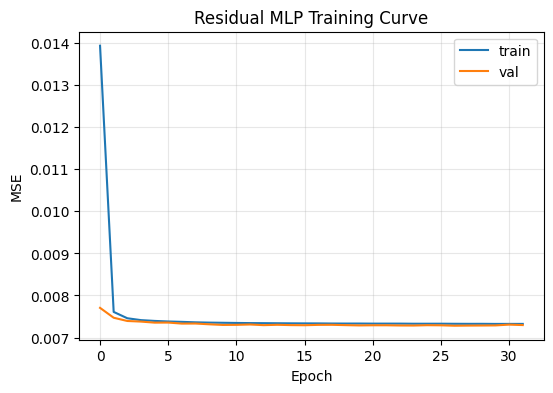

Best val MSE      : 0.00728070
Test RMSE before: 5.752162
Test RMSE after : 1.281872
Test MAE before : 4.095959
Test MAE after  : 0.714228


In [13]:
train_loader = make_loader(X_train, Y_train, batch_size=4096, shuffle=True)
val_loader = make_loader(X_val, Y_val, batch_size=4096, shuffle=False)

model = DenoisingResidualMLP().to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)

MAX_EPOCHS = 33
PATIENCE = 5
best_val = float("inf")
best_state = None
no_improve_count = 0
train_losses, val_losses = [], []

for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss = run_epoch(model, train_loader, criterion, optimizer=optimizer)
    va_loss = run_epoch(model, val_loader, criterion, optimizer=None)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)

    if va_loss < best_val:
        best_val = va_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        no_improve_count = 0
    else:
        no_improve_count += 1

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:03d}/{MAX_EPOCHS} | train={tr_loss:.8f} | "
            f"val={va_loss:.8f} | no_improve={no_improve_count}/{PATIENCE}"
        )

    if no_improve_count >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch} (patience={PATIENCE}).")
        break

if best_state is not None:
    model.load_state_dict(best_state)

plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Residual MLP Training Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# test evaluation in physical distance domain
pred_noise_test = predict_noise(model, X_test)
clean_pred_test = (X_test[:, :4] - pred_noise_test) * DIST_NORM

rmse_before = np.sqrt(np.mean((D_noisy_test - D_true_test) ** 2))
rmse_after = np.sqrt(np.mean((clean_pred_test - D_true_test) ** 2))
mae_before = np.mean(np.abs(D_noisy_test - D_true_test))
mae_after = np.mean(np.abs(clean_pred_test - D_true_test))

print(f"Best val MSE      : {best_val:.8f}")
print(f"Test RMSE before: {rmse_before:.6f}")
print(f"Test RMSE after : {rmse_after:.6f}")
print(f"Test MAE before : {mae_before:.6f}")
print(f"Test MAE after  : {mae_after:.6f}")

In [14]:
# full inference on all samples
pred_noise_full = predict_noise(model, X_input)
clean_full_flat = (X_input[:, :4] - pred_noise_full) * DIST_NORM

# (M,4) -> (4, P, S, N)
clean_full_4psn = clean_full_flat.reshape(P, S, N, 4).transpose(3, 0, 1, 2).astype(np.float32)

# save corrected h5 with original layout compatibility
raw_ranging_shape = raw_data["ranging"].shape
clean_h5 = to_original_ranging_layout(clean_full_4psn, raw_ranging_shape)

# 눈으로 확인: 저장 직전 보정값 샘플
print("Preview corrected (anchor0, point0, sample0, all-noise):")
print(clean_full_4psn[0, 0, 0, :])
print("Preview original measured (anchor0, point0, sample0, all-noise):")
print(ranging_meas[0, 0, 0, :])

with h5py.File(H5_IN, "r") as src, h5py.File(H5_OUT, "w") as dst:
    for key in src.keys():
        src.copy(key, dst)

    dst.create_dataset("ranging_corrected", data=clean_h5, compression="gzip")
    dst.attrs["model_type"] = "DenoisingResidualMLP"
    dst.attrs["residual_target"] = "(d_meas-d_true)/15.0"
    dst.attrs["sigma_max"] = float(SIGMA_MAX)
    dst.attrs["dist_norm"] = float(DIST_NORM)

print("Saved corrected h5:", H5_OUT)
with h5py.File(H5_OUT, "r") as h5:
    print("ranging original shape :", h5["ranging"].shape)
    print("ranging_corrected shape:", h5["ranging_corrected"].shape)
    print("Saved corrected sample (h5 layout [noise, point, sample, anchor]):")
    print(h5["ranging_corrected"][0, 0, 0, :])

Preview corrected (anchor0, point0, sample0, all-noise):
[12.402098  12.3708    12.587544  12.0683565  9.574464 ]
Preview original measured (anchor0, point0, sample0, all-noise):
[ 9.088427  8.671268  6.85798  10.936177 20.070162]
Saved corrected h5: c:\Users\myhom\codebase\localization-filters-2d\data\simulation_data_residual_mlp_corrected.h5
ranging original shape : (5, 100000, 10, 4)
ranging_corrected shape: (5, 100000, 10, 4)
Saved corrected sample (h5 layout [noise, point, sample, anchor]):
[12.402098   9.1748905  1.8441412  8.50905  ]


In [15]:
# matching test: true ranging vs corrected ranging
# 1) in-memory corrected tensor alignment check
print("[Matching Test] in-memory tensor check")
print("ranging_true shape     :", ranging_true.shape)
print("clean_full_4psn shape  :", clean_full_4psn.shape)

if clean_full_4psn.shape != ranging_true.shape:
    raise ValueError("Shape mismatch between corrected and true ranging tensors")

rmse_raw = float(np.sqrt(np.mean((ranging_meas - ranging_true) ** 2)))
rmse_corr = float(np.sqrt(np.mean((clean_full_4psn - ranging_true) ** 2)))
mae_raw = float(np.mean(np.abs(ranging_meas - ranging_true)))
mae_corr = float(np.mean(np.abs(clean_full_4psn - ranging_true)))

print(f"RMSE raw   vs true: {rmse_raw:.6f}")
print(f"RMSE corr  vs true: {rmse_corr:.6f}")
print(f"MAE  raw   vs true: {mae_raw:.6f}")
print(f"MAE  corr  vs true: {mae_corr:.6f}")

# 2) saved h5 corrected tensor alignment check
print("\n[Matching Test] saved h5 check")
with h5py.File(H5_OUT, "r") as h5:
    saved_corr_h5 = np.asarray(h5["ranging_corrected"])

saved_corr_internal = swap_first_last_dims(saved_corr_h5).astype(np.float32)
print("saved_corr_internal shape:", saved_corr_internal.shape)

max_abs_diff = float(np.max(np.abs(saved_corr_internal - clean_full_4psn)))
print(f"max |saved - in_memory|: {max_abs_diff:.8f}")

# 3) index-level spot check (anchor, point, sample, noise)
check_indices = [
    (0, 0, 0, 0),
    (1, 1, 0, 1),
    (2, min(2, P - 1), 0, 2),
    (3, min(3, P - 1), 0, min(4, N - 1)),
]

print("\n[Matching Test] sample values")
for a, p, s, n in check_indices:
    true_v = float(ranging_true[a, p, s, n])
    raw_v = float(ranging_meas[a, p, s, n])
    corr_v = float(clean_full_4psn[a, p, s, n])
    print(
        f"idx(a={a}, p={p}, s={s}, n={n}) | "
        f"true={true_v:.6f}, raw={raw_v:.6f}, corrected={corr_v:.6f}"
    )

[Matching Test] in-memory tensor check
ranging_true shape     : (4, 10, 100000, 5)
clean_full_4psn shape  : (4, 10, 100000, 5)
RMSE raw   vs true: 5.747231
RMSE corr  vs true: 1.282409
MAE  raw   vs true: 4.093366
MAE  corr  vs true: 0.714179

[Matching Test] saved h5 check
saved_corr_internal shape: (4, 10, 100000, 5)
max |saved - in_memory|: 0.00000000

[Matching Test] sample values
idx(a=0, p=0, s=0, n=0) | true=12.478611, raw=9.088427, corrected=12.402098
idx(a=1, p=1, s=0, n=1) | true=8.717798, raw=3.014804, corrected=8.842328
idx(a=2, p=2, s=0, n=2) | true=4.866676, raw=8.886879, corrected=4.641674
idx(a=3, p=3, s=0, n=4) | true=5.161479, raw=9.503504, corrected=5.126696


In [16]:
# export model files for interoperability
# 1) regular checkpoint (.pt)
checkpoint_out = PT_OUT
# 2) TorchScript traced model (.pt) for converter workflows
traced_out = RESULT_DIR / "denoising_residual_mlp_traced.pt"

model_payload = {
    "model_state_dict": model.state_dict(),
    "model_class": "DenoisingResidualMLP",
    "input_dim": 5,
    "hidden_dims": [64, 64],
    "activation": "GELU",
    "output_dim": 4,
    "dist_norm": float(DIST_NORM),
    "sigma_max": float(SIGMA_MAX),
    "sigma_by_noise": sigma_by_noise.tolist(),
    "anchors": anchors.tolist(),
    "best_val_mse": float(best_val),
    "seed": int(SEED),
    "pytorch_version": torch.__version__,
}

torch.save(model_payload, checkpoint_out)

# Trace in eval mode with representative 5-D input: [d1,d2,d3,d4,sigma_norm]
model.eval()
example_input = torch.randn(1, 5, dtype=torch.float32, device=DEVICE)
traced_model = torch.jit.trace(model, example_input)
traced_model.save(str(traced_out))

print("Saved checkpoint:", checkpoint_out)
print("Saved traced model:", traced_out)
print("PyTorch version:", torch.__version__)

Saved checkpoint: c:\Users\myhom\codebase\localization-filters-2d\result\denoising_residual_mlp.pt
Saved traced model: c:\Users\myhom\codebase\localization-filters-2d\result\denoising_residual_mlp_traced.pt
PyTorch version: 2.9.1+cu128


## Execution Order
1. Cell 2 to Cell 4: package import, data load, dataset build
2. Cell 5: model and helper definitions
3. Cell 6: training and test-domain evaluation
4. Cell 7: corrected ranging save to h5
5. Cell 8: checkpoint pt and traced TorchScript pt save

## Notes
- Anchor channel order is preserved as loaded.
- Output layer is linear to allow positive and negative AWGN residual prediction.
- Residual learning formula is used exactly in training and reconstruction.
- Deep Learning Toolbox Converter for PyTorch Models workflow uses the traced file from Cell 8.